# Population Sweep Analysis

Tables on final-state outcomes and Figures on temporal dynamics

**Key notes:**
- Emotions are in [0, 1] range (not [-1, 1])
- 30 seeds per condition (not 100, for initial analysis and speed)
- 4 population sizes: 11, 41, 81, 111
- 2 conditions: adaptive (TT) and fixed (FT) intimacy
- 3 leader styles (None, Low, High) (they still use RL to dictate intervention strength)
- 3 structures × 3 leader styles = 9 conditions per (size, combo)

## Setup & Imports

In [1]:
import sys
import pickle
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['figure.dpi'] = 120

# Add source dirs to sys.path so pickled objects can find their modules
sys.path.insert(0, str(Path('../src').resolve()))
sys.path.insert(0, str(Path('../running').resolve()))

OUTPUTS_DIR = Path('../outputs').resolve()
print(f'Outputs dir: {OUTPUTS_DIR}')

class _Dummy:
    def __init__(self, *args, **kwargs):
        pass
    def __setstate__(self, state):
        pass

class SafeUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module.startswith('pandas'):
            return _Dummy
        return super().find_class(module, name)

Outputs dir: C:\Users\sarah\Downloads\Emotion-Contagion\BigProject\outputs


Each of the 12 timestamped folders has a `combination.txt` specifying the adaptive/fixed flag and population size, plus a condition folder with `.pkl` result files.

In [2]:
def parse_combination_file(batch_dir):
    """Read combination.txt and return (adaptive_bool, leader_ties_bool, combo_code, pop_size)."""
    combo_path = batch_dir / 'combination.txt'
    if not combo_path.exists():
        return None, None, None, None
    lines = combo_path.read_text().strip().split('\n')
    combo_code = None
    adaptive = None
    leader_ties = None
    pop_size = None
    for line in lines:
        if line.startswith('combination'):
            combo_code = line.split('=')[1].strip()
        elif line.startswith('adaptive_intimacy'):
            adaptive = line.split('=')[1].strip() == 'True'
        elif line.startswith('include_leader_ties'):
            leader_ties = line.split('=')[1].strip() == 'True'
        elif line.startswith('population_size'):
            pop_size = int(line.split('=')[1].strip())
    return adaptive, leader_ties, combo_code, pop_size

def find_all_batches(outputs_dir):
    """Find all batch directories that have a combination.txt file."""
    batches = []
    for d in sorted(outputs_dir.iterdir()):
        if not d.is_dir():
            continue
        combo = d / 'combination.txt'
        if combo.exists():
            adaptive, leader_ties, code, pop_size = parse_combination_file(d)
            if adaptive is not None and pop_size is not None:
                label = f"{'Adaptive' if adaptive else 'Fixed'}_N{pop_size}"
                batches.append({
                    'dir': d,
                    'adaptive': adaptive,
                    'leader_ties': leader_ties,
                    'combo_code': code,
                    'pop_size': pop_size,
                    'label': label
                })
    # Deduplicate by (adaptive, pop_size) — keep most recent
    deduped = {}
    for b in batches:
        key = (b['adaptive'], b['pop_size'])
        if key not in deduped or b['dir'].name > deduped[key]['dir'].name:
            deduped[key] = b
    return sorted(deduped.values(), key=lambda b: (b['pop_size'], not b['adaptive']))

batches = find_all_batches(OUTPUTS_DIR)
print(f'Found {len(batches)} condition batches:')
for b in batches:
    print(f"  {b['label']:20s}  combo={b['combo_code']}  dir={b['dir'].name}")

Found 8 condition batches:
  Adaptive_N11          combo=TT  dir=2026-10-07_13-46-16
  Fixed_N11             combo=FT  dir=2026-10-07_13-47-33
  Adaptive_N41          combo=TT  dir=2026-10-07_13-48-37
  Fixed_N41             combo=FT  dir=2026-10-07_13-58-28
  Adaptive_N81          combo=TT  dir=2026-10-07_14-08-33
  Fixed_N81             combo=FT  dir=2026-10-07_14-45-39
  Adaptive_N111         combo=TT  dir=2026-10-07_15-22-28
  Fixed_N111            combo=FT  dir=2026-10-07_16-27-58


Load and extract data

In [3]:
# Threshold for "negative tail" — proportion of members below this value.
NEGATIVE_TAIL_THRESHOLD = 0.2  # 0.2 captures members who remain in the initial low range rather than improving.

# Number of final timesteps to average over for Table 1 (final-state outcomes)
FINAL_WINDOW = 20  # last 20 timesteps (t = 281-300)

summary_rows = []
trajectory_rows = []

for batch in batches:
    # Find all pkl files in any subdirectory (handles both old 'unnamed_condition' and new named condition folders)

    pkl_files = sorted(p for p in batch['dir'].rglob('simulation_result_run_*.pkl') if '_qtable' not in p.name)
    print(f"Loading {len(pkl_files)} runs for {batch['label']}...")

    for p in pkl_files:
        with open(p, 'rb') as f:
            r = SafeUnpickler(f).load()

        # Extract metadata
        structure = r.metadata.get('structure')
        leader_style = r.metadata.get('leader_style')
        pop_size = batch['pop_size']
        adaptive = batch['adaptive']

        # Final-state summary (averaged over last FINAL_WINDOW timesteps)
        # emotion_history[t] = list of all agent emotions at timestep t (leader is last)
        n_total = len(r.emotion_history)
        start_t = max(0, n_total - FINAL_WINDOW)

        final_mean_emotions = []
        final_variances = []
        final_neg_tails = []
        final_p10s = []

        for t in range(start_t, n_total):
            member_emotions = r.emotion_history[t][:-1]  # exclude leader (last agent)
            member_emotions = np.array(member_emotions)
            final_mean_emotions.append(np.mean(member_emotions))
            final_variances.append(np.var(member_emotions))
            final_neg_tails.append(np.mean(member_emotions < NEGATIVE_TAIL_THRESHOLD))
            final_p10s.append(np.percentile(member_emotions, 10))

        h_arr = np.asarray(r.homophily_history, dtype=float) if r.homophily_history else np.array([np.nan])
        h_valid = h_arr[~np.isnan(h_arr)]

        summary_rows.append({
            'run_id': r.run_id,
            'seed': r.seed,
            'pop_size': pop_size,
            'adaptive': adaptive,
            'condition': batch['label'],
            'structure': structure,
            'leader_style': leader_style,
            'final_mean_emotion': float(np.mean(final_mean_emotions)),
            'final_variance': float(np.mean(final_variances)),
            'final_neg_tail': float(np.mean(final_neg_tails)),
            'final_p10': float(np.mean(final_p10s)),
            'final_homophily': float(h_arr[-1]) if len(h_arr) > 0 else np.nan,
            'num_interventions': len(r.intervention_timesteps),
            'first_intervention': r.intervention_timesteps[0] if r.intervention_timesteps else None,
            'n_timesteps': n_total,
        })

        # Trajectory (one row per timestep)
        for t in range(n_total):
            member_emotions = np.array(r.emotion_history[t][:-1])
            trajectory_rows.append({
                'run_id': r.run_id,
                'seed': r.seed,
                'pop_size': pop_size,
                'adaptive': adaptive,
                'condition': batch['label'],
                'structure': structure,
                'leader_style': leader_style,
                'timestep': t,
                'avg_emotion': float(np.mean(member_emotions)),
                'variance': float(np.var(member_emotions)),
                'neg_tail': float(np.mean(member_emotions < NEGATIVE_TAIL_THRESHOLD)),
                'homophily': r.homophily_history[t] if t < len(r.homophily_history) else np.nan,
            })

        del r  # critical: free the full object before loading the next one

print(f'\nTotal runs loaded: {len(summary_rows)}')
print(f'Trajectory rows: {len(trajectory_rows):,}')

Loading 270 runs for Adaptive_N11...
Loading 270 runs for Fixed_N11...
Loading 270 runs for Adaptive_N41...
Loading 270 runs for Fixed_N41...
Loading 270 runs for Adaptive_N81...
Loading 270 runs for Fixed_N81...
Loading 270 runs for Adaptive_N111...
Loading 270 runs for Fixed_N111...

Total runs loaded: 2160
Trajectory rows: 650,160


In [4]:
summary_df = pd.DataFrame(summary_rows)
trajectory_df = pd.DataFrame(trajectory_rows)

print(f'Summary: {summary_df.shape}')
print(f'Trajectory: {trajectory_df.shape}')
print()
print('Population sizes:', sorted(summary_df['pop_size'].unique()))
print('Structures:', sorted(summary_df['structure'].unique()))
print('Leader styles:', sorted(summary_df['leader_style'].unique()))
print('Adaptive conditions:', sorted(summary_df['adaptive'].unique()))
print()
print('Runs per condition:')
print(summary_df.groupby(['pop_size', 'adaptive', 'structure', 'leader_style']).size())

# Display labels and ordering for tables
style_labels = {
    'No_Intervention': 'No Intervention',
    'Low_Fully_Constrained': 'Low Aperture',
    'High_Fully_Constrained': 'High Aperture'
}
structure_order = ['random', 'community', 'core_periphery']
style_order = ['No_Intervention', 'Low_Fully_Constrained', 'High_Fully_Constrained']

Summary: (2160, 15)
Trajectory: (650160, 12)

Population sizes: [np.int64(11), np.int64(41), np.int64(81), np.int64(111)]
Structures: ['community', 'core_periphery', 'random']
Leader styles: ['High_Fully_Constrained', 'Low_Fully_Constrained', 'No_Intervention']
Adaptive conditions: [np.False_, np.True_]

Runs per condition:
pop_size  adaptive  structure       leader_style          
11        False     community       High_Fully_Constrained    30
                                    Low_Fully_Constrained     30
                                    No_Intervention           30
                    core_periphery  High_Fully_Constrained    30
                                    Low_Fully_Constrained     30
                                                              ..
111       True      core_periphery  Low_Fully_Constrained     30
                                    No_Intervention           30
                    random          High_Fully_Constrained    30
                              

### Tables: Final-State Collective Emotional Outcomes across all population sizes

mean emotion, variance, negative tail, 10th percentile, first convergence

In [5]:
# mean emotion
for adaptive_val in [True, False]:
    cond_label = 'Adaptive' if adaptive_val else 'Fixed'
    print(f'\n{cond_label} intimacy — Final Mean Emotion')
    print(f'{"Structure":<18s} {"Leader style":<28s}', end='')
    for n in sorted(summary_df['pop_size'].unique()):
        print(f'{f"N={n}":>12s}', end='')
    print()
    print('-' * (18 + 28 + 12 * len(summary_df['pop_size'].unique())))

    for struct in structure_order:
        for style in style_order:
            cell = summary_df[(summary_df['adaptive'] == adaptive_val) & (summary_df['structure'] == struct) & (summary_df['leader_style'] == style)]
            if len(cell) == 0:
                continue
            print(f'{struct:<18s} {style_labels[style]:<28s}', end='')
            for n in sorted(summary_df['pop_size'].unique()):
                vals = cell[cell['pop_size'] == n]['final_mean_emotion']
                if len(vals) > 0:
                    print(f'{vals.mean():>12.4f}', end='')
                else:
                    print(f'{"—":>12s}', end='')
            print()


Adaptive intimacy — Final Mean Emotion
Structure          Leader style                        N=11        N=41        N=81       N=111
----------------------------------------------------------------------------------------------
random             No Intervention                   0.0957      0.0992      0.0991      0.0991
random             Low Aperture                      0.1523      0.1504      0.1486      0.1439
random             High Aperture                     0.2523      0.2263      0.1770      0.1530
community          No Intervention                   0.0979      0.1006      0.0988      0.0986
community          Low Aperture                      0.1535      0.1505      0.1482      0.1434
community          High Aperture                     0.2524      0.2293      0.1762      0.1521
core_periphery     No Intervention                   0.0997      0.1000      0.1003      0.0994
core_periphery     Low Aperture                      0.1590      0.1506      0.1479      0.1445
c

In [6]:
# variance
for adaptive_val in [True, False]:
    cond_label = 'Adaptive' if adaptive_val else 'Fixed'
    print(f'\n{cond_label} intimacy — Final Variance')
    print(f'{"Structure":<18s} {"Leader style":<28s}', end='')
    for n in sorted(summary_df['pop_size'].unique()):
        print(f'{f"N={n}":>12s}', end='')
    print()
    print('-' * (18 + 28 + 12 * len(summary_df['pop_size'].unique())))

    for struct in structure_order:
        for style in style_order:
            cell = summary_df[(summary_df['adaptive'] == adaptive_val) & (summary_df['structure'] == struct) & (summary_df['leader_style'] == style)]
            if len(cell) == 0:
                continue
            print(f'{struct:<18s} {style_labels[style]:<28s}', end='')
            for n in sorted(summary_df['pop_size'].unique()):
                vals = cell[cell['pop_size'] == n]['final_variance']
                if len(vals) > 0:
                    print(f'{vals.mean():>12.4f}', end='')
                else:
                    print(f'{"—":>12s}', end='')
            print()


Adaptive intimacy — Final Variance
Structure          Leader style                        N=11        N=41        N=81       N=111
----------------------------------------------------------------------------------------------
random             No Intervention                   0.0000      0.0000      0.0000      0.0000
random             Low Aperture                      0.0000      0.0000      0.0000      0.0000
random             High Aperture                     0.0000      0.0000      0.0000      0.0000
community          No Intervention                   0.0000      0.0000      0.0000      0.0000
community          Low Aperture                      0.0000      0.0000      0.0000      0.0000
community          High Aperture                     0.0000      0.0000      0.0000      0.0000
core_periphery     No Intervention                   0.0000      0.0000      0.0000      0.0000
core_periphery     Low Aperture                      0.0001      0.0000      0.0000      0.0000
core_

In [7]:
# negative tail
for adaptive_val in [True, False]:
    cond_label = 'Adaptive' if adaptive_val else 'Fixed'
    print(f'\n{cond_label} intimacy — Final Negative Tail')
    print(f'{"Structure":<18s} {"Leader style":<28s}', end='')
    for n in sorted(summary_df['pop_size'].unique()):
        print(f'{f"N={n}":>12s}', end='')
    print()
    print('-' * (18 + 28 + 12 * len(summary_df['pop_size'].unique())))

    for struct in structure_order:
        for style in style_order:
            cell = summary_df[(summary_df['adaptive'] == adaptive_val) & (summary_df['structure'] == struct) & (summary_df['leader_style'] == style)]
            if len(cell) == 0:
                continue
            print(f'{struct:<18s} {style_labels[style]:<28s}', end='')
            for n in sorted(summary_df['pop_size'].unique()):
                vals = cell[cell['pop_size'] == n]['final_neg_tail']
                if len(vals) > 0:
                    print(f'{vals.mean():>12.4f}', end='')
                else:
                    print(f'{"—":>12s}', end='')
            print()


Adaptive intimacy — Final Negative Tail
Structure          Leader style                        N=11        N=41        N=81       N=111
----------------------------------------------------------------------------------------------
random             No Intervention                   1.0000      1.0000      1.0000      1.0000
random             Low Aperture                      1.0000      1.0000      1.0000      1.0000
random             High Aperture                     0.0000      0.1999      0.8759      1.0000
community          No Intervention                   1.0000      1.0000      1.0000      1.0000
community          Low Aperture                      1.0000      1.0000      1.0000      1.0000
community          High Aperture                     0.0000      0.1000      0.8036      1.0000
core_periphery     No Intervention                   1.0000      1.0000      1.0000      1.0000
core_periphery     Low Aperture                      0.9288      1.0000      1.0000      1.0000


In [8]:
# p10
for adaptive_val in [True, False]:
    cond_label = 'Adaptive' if adaptive_val else 'Fixed'
    print(f'\n{cond_label} intimacy — Final p10')
    print(f'{"Structure":<18s} {"Leader style":<28s}', end='')
    for n in sorted(summary_df['pop_size'].unique()):
        print(f'{f"N={n}":>12s}', end='')
    print()
    print('-' * (18 + 28 + 12 * len(summary_df['pop_size'].unique())))

    for struct in structure_order:
        for style in style_order:
            cell = summary_df[(summary_df['adaptive'] == adaptive_val) & (summary_df['structure'] == struct) & (summary_df['leader_style'] == style)]
            if len(cell) == 0:
                continue
            print(f'{struct:<18s} {style_labels[style]:<28s}', end='')
            for n in sorted(summary_df['pop_size'].unique()):
                vals = cell[cell['pop_size'] == n]['final_p10']
                if len(vals) > 0:
                    print(f'{vals.mean():>12.4f}', end='')
                else:
                    print(f'{"—":>12s}', end='')
            print()


Adaptive intimacy — Final p10
Structure          Leader style                        N=11        N=41        N=81       N=111
----------------------------------------------------------------------------------------------
random             No Intervention                   0.0957      0.0992      0.0991      0.0991
random             Low Aperture                      0.1523      0.1504      0.1485      0.1434
random             High Aperture                     0.2523      0.2246      0.1751      0.1517
community          No Intervention                   0.0979      0.1006      0.0988      0.0986
community          Low Aperture                      0.1535      0.1505      0.1481      0.1429
community          High Aperture                     0.2523      0.2269      0.1745      0.1507
core_periphery     No Intervention                   0.0996      0.1000      0.1003      0.0994
core_periphery     Low Aperture                      0.1562      0.1506      0.1477      0.1440
core_perip

In [9]:
# First Convergence -- first timestep where within-team emotion variance <= threshold
CONVERGENCE_THRESHOLD = 0.01

# Compute per run from trajectory_df
convergence_rows = []
for (run_id, seed), grp in trajectory_df.groupby(['run_id', 'seed']):
    grp = grp.sort_values('timestep')
    converged = grp[grp['variance'] <= CONVERGENCE_THRESHOLD]
    if len(converged) > 0:
        first_t = int(converged['timestep'].iloc[0])
    else:
        first_t = None  # never converged within the simulation
    convergence_rows.append({'run_id': run_id, 'seed': seed, 'first_convergence': first_t})

convergence_df = pd.DataFrame(convergence_rows)
if 'first_convergence' in summary_df.columns:
    summary_df = summary_df.drop(columns=['first_convergence'])
summary_df = summary_df.merge(convergence_df, on=['run_id', 'seed'], how='left')

for adaptive_val in [True, False]:
    cond_label = 'Adaptive' if adaptive_val else 'Fixed'
    print(f'\n{cond_label} intimacy -- First Convergence (variance <= {CONVERGENCE_THRESHOLD})')
    print(f'{"Structure":<18s} {"Leader style":<28s}', end='')
    for n in sorted(summary_df['pop_size'].unique()):
        print(f'{f"N={n}":>12s}', end='')
    print()
    print('-' * (18 + 28 + 12 * len(summary_df['pop_size'].unique())))

    for struct in structure_order:
        for style in style_order:
            cell = summary_df[(summary_df['adaptive'] == adaptive_val) & (summary_df['structure'] == struct) & (summary_df['leader_style'] == style)]
            if len(cell) == 0:
                continue
            print(f'{struct:<18s} {style_labels[style]:<28s}', end='')
            for n in sorted(summary_df['pop_size'].unique()):
                vals = cell[cell['pop_size'] == n]['first_convergence']
                if len(vals) > 0:
                    mean_val = vals.mean()
                    if pd.isna(mean_val):
                        print(f'{"never":>12s}', end='')
                    else:
                        print(f'{mean_val:>12.1f}', end='')
                else:
                    print(f'{"---":>12s}', end='')
            print()


Adaptive intimacy -- First Convergence (variance <= 0.01)
Structure          Leader style                        N=11        N=41        N=81       N=111
----------------------------------------------------------------------------------------------
random             No Intervention                      0.0         0.0         0.0         0.0
random             Low Aperture                         0.0         0.0         0.0         0.0
random             High Aperture                        0.0         0.0         0.0         0.0
community          No Intervention                      0.0         0.0         0.0         0.0
community          Low Aperture                         0.0         0.0         0.0         0.0
community          High Aperture                        0.0         0.0         0.0         0.0
core_periphery     No Intervention                      0.0         0.0         0.0         0.0
core_periphery     Low Aperture                         0.0         0.0       

## 5. Temporal Dynamics Figures

Each panel shows 3 lines (one per network structure). Lines are condition means across seeds; shaded bands are ±1 SE.

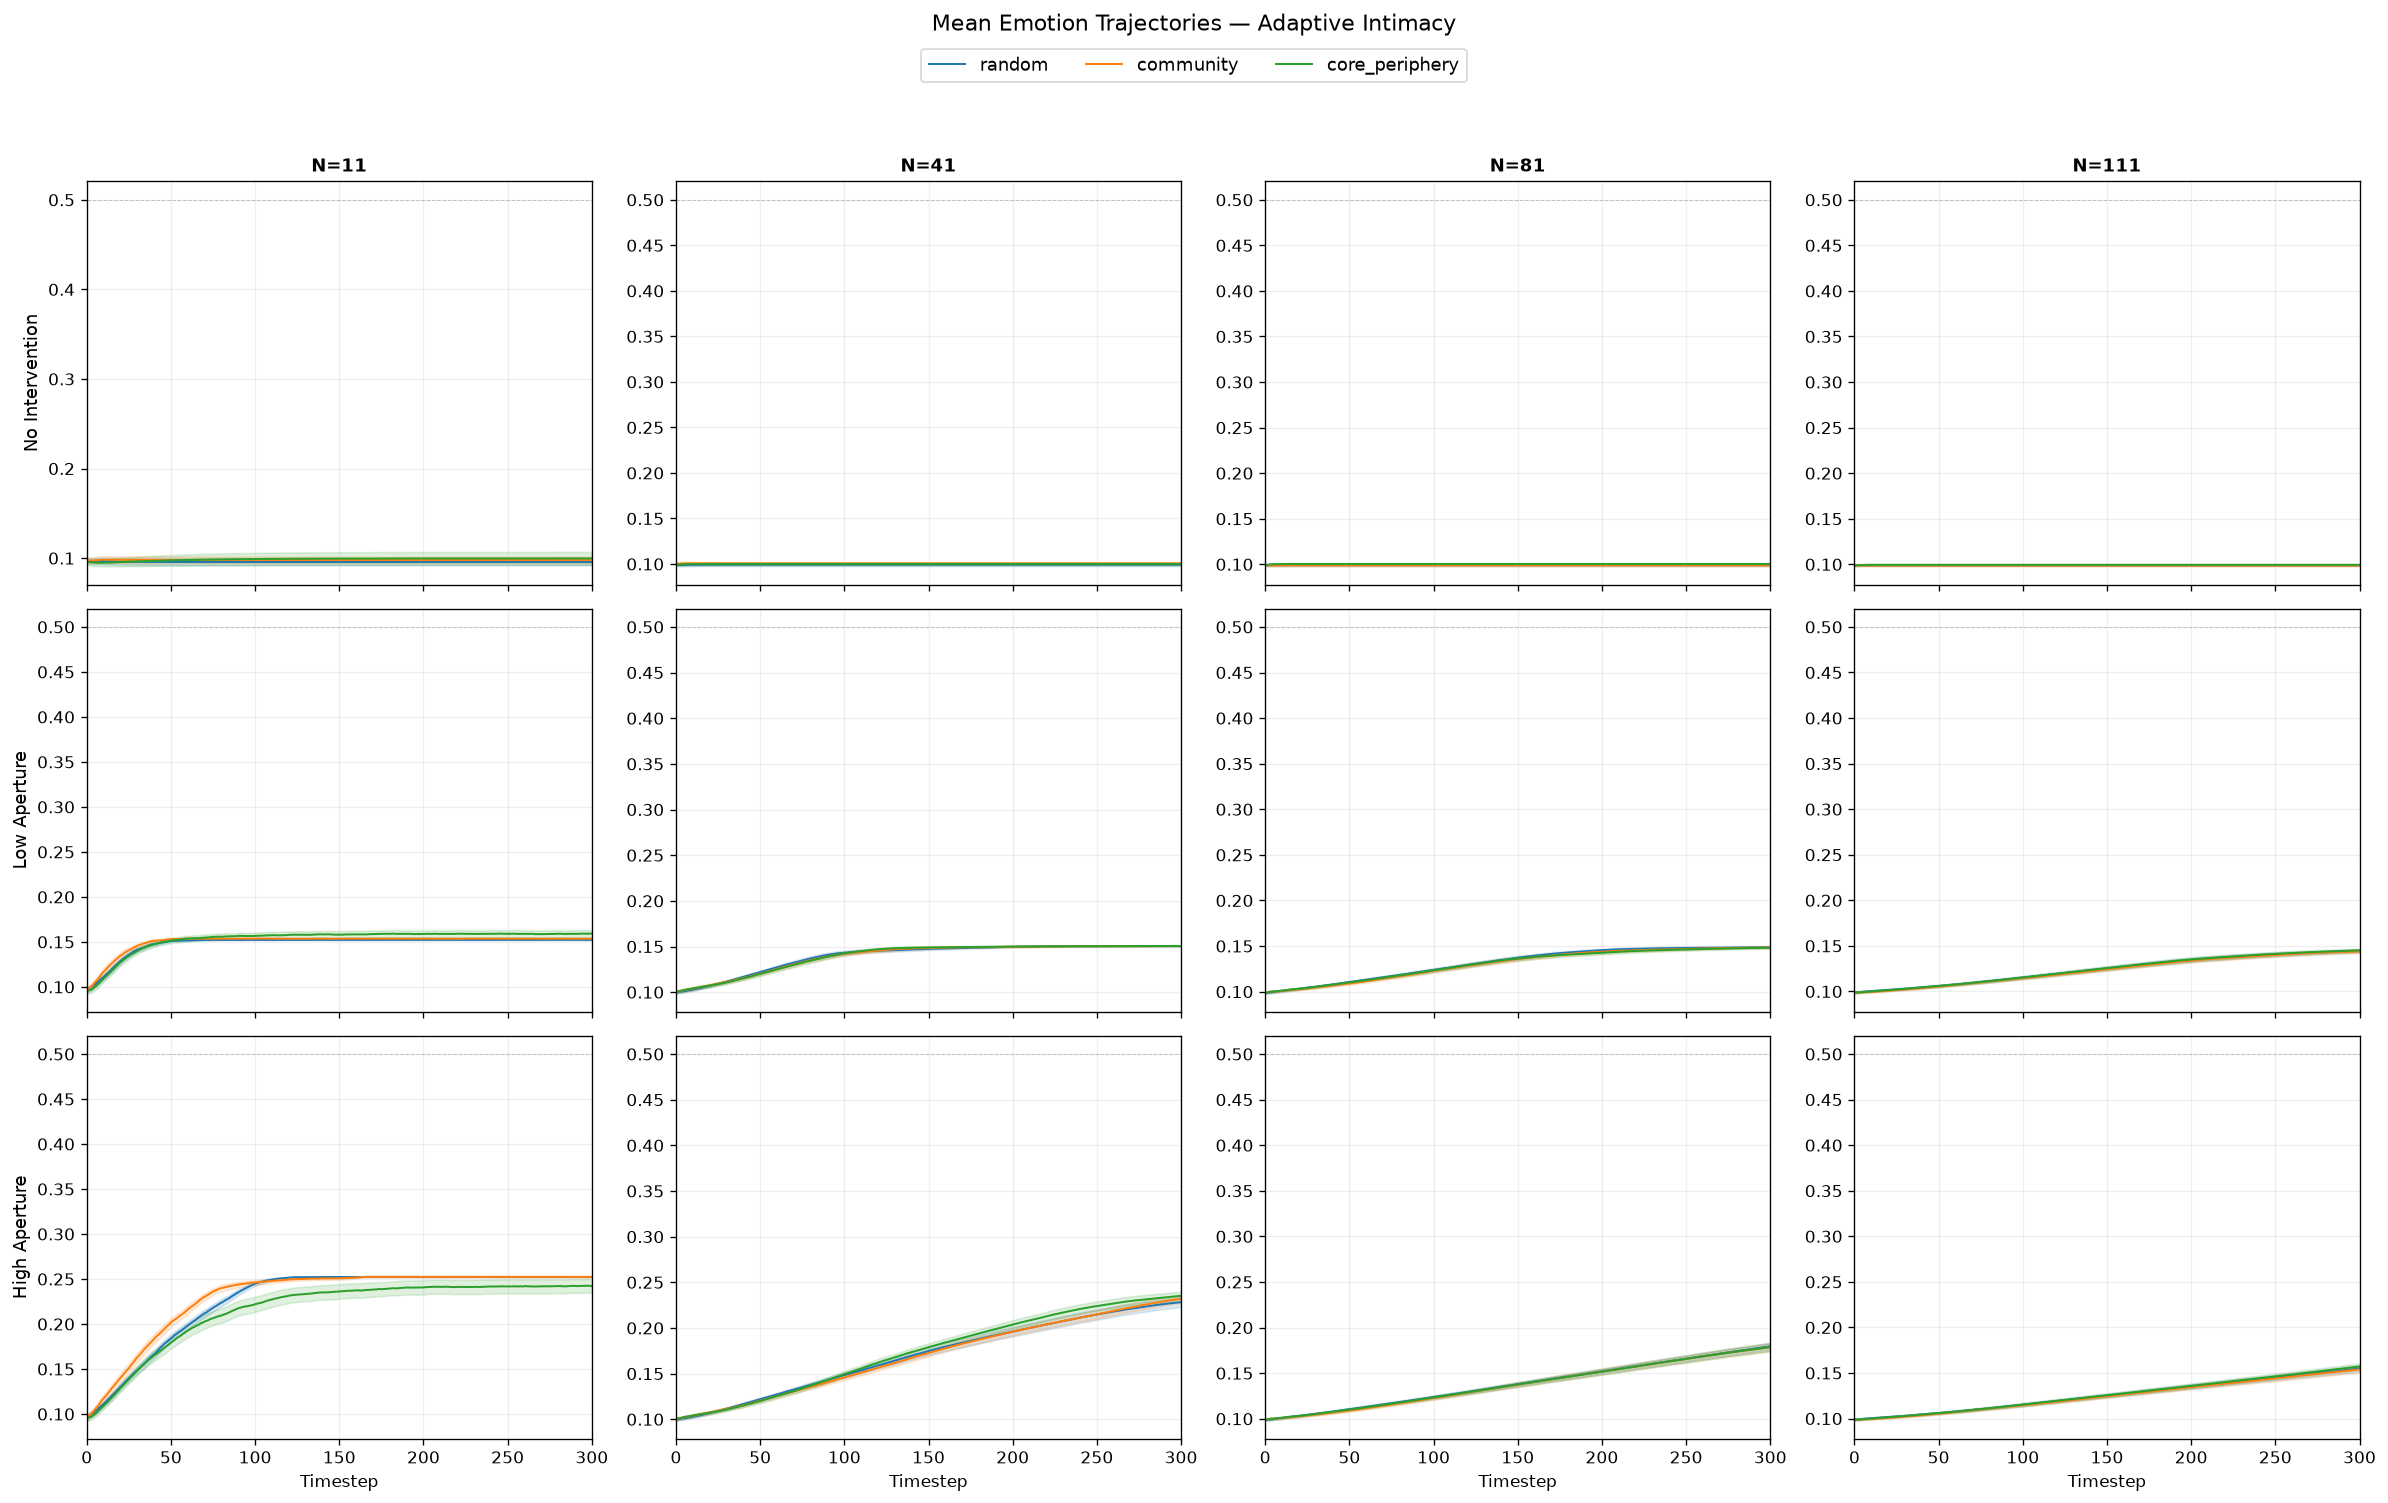

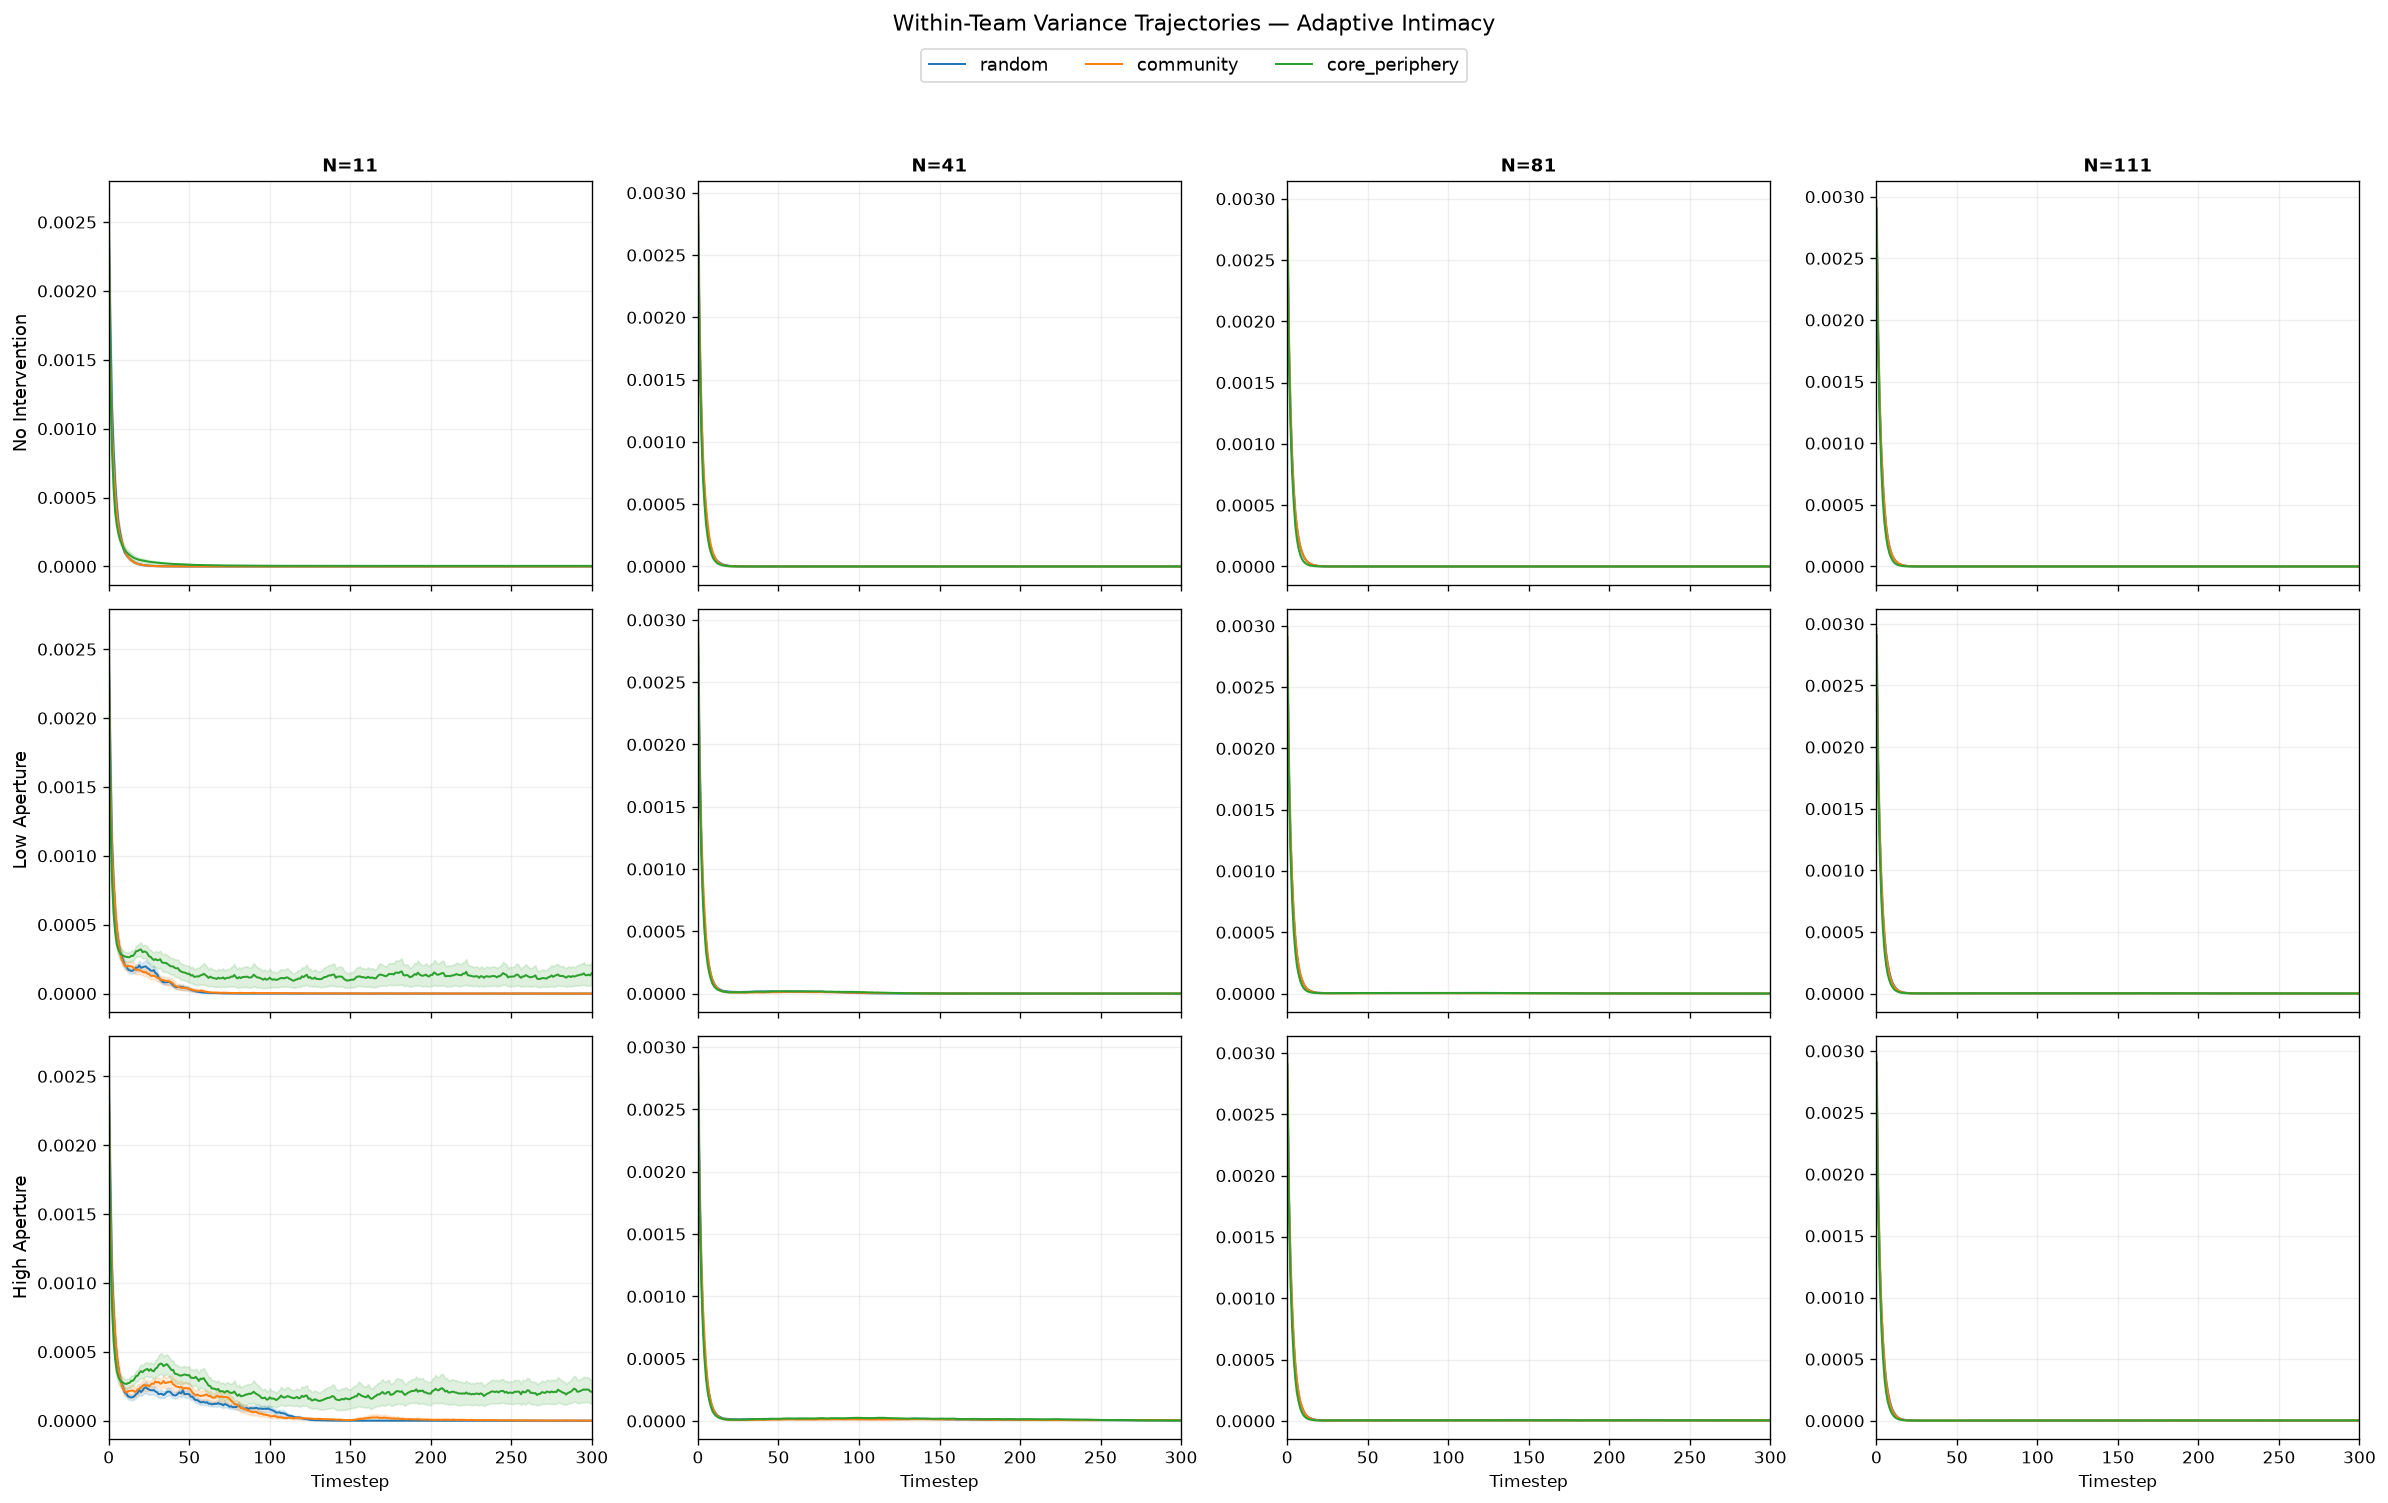

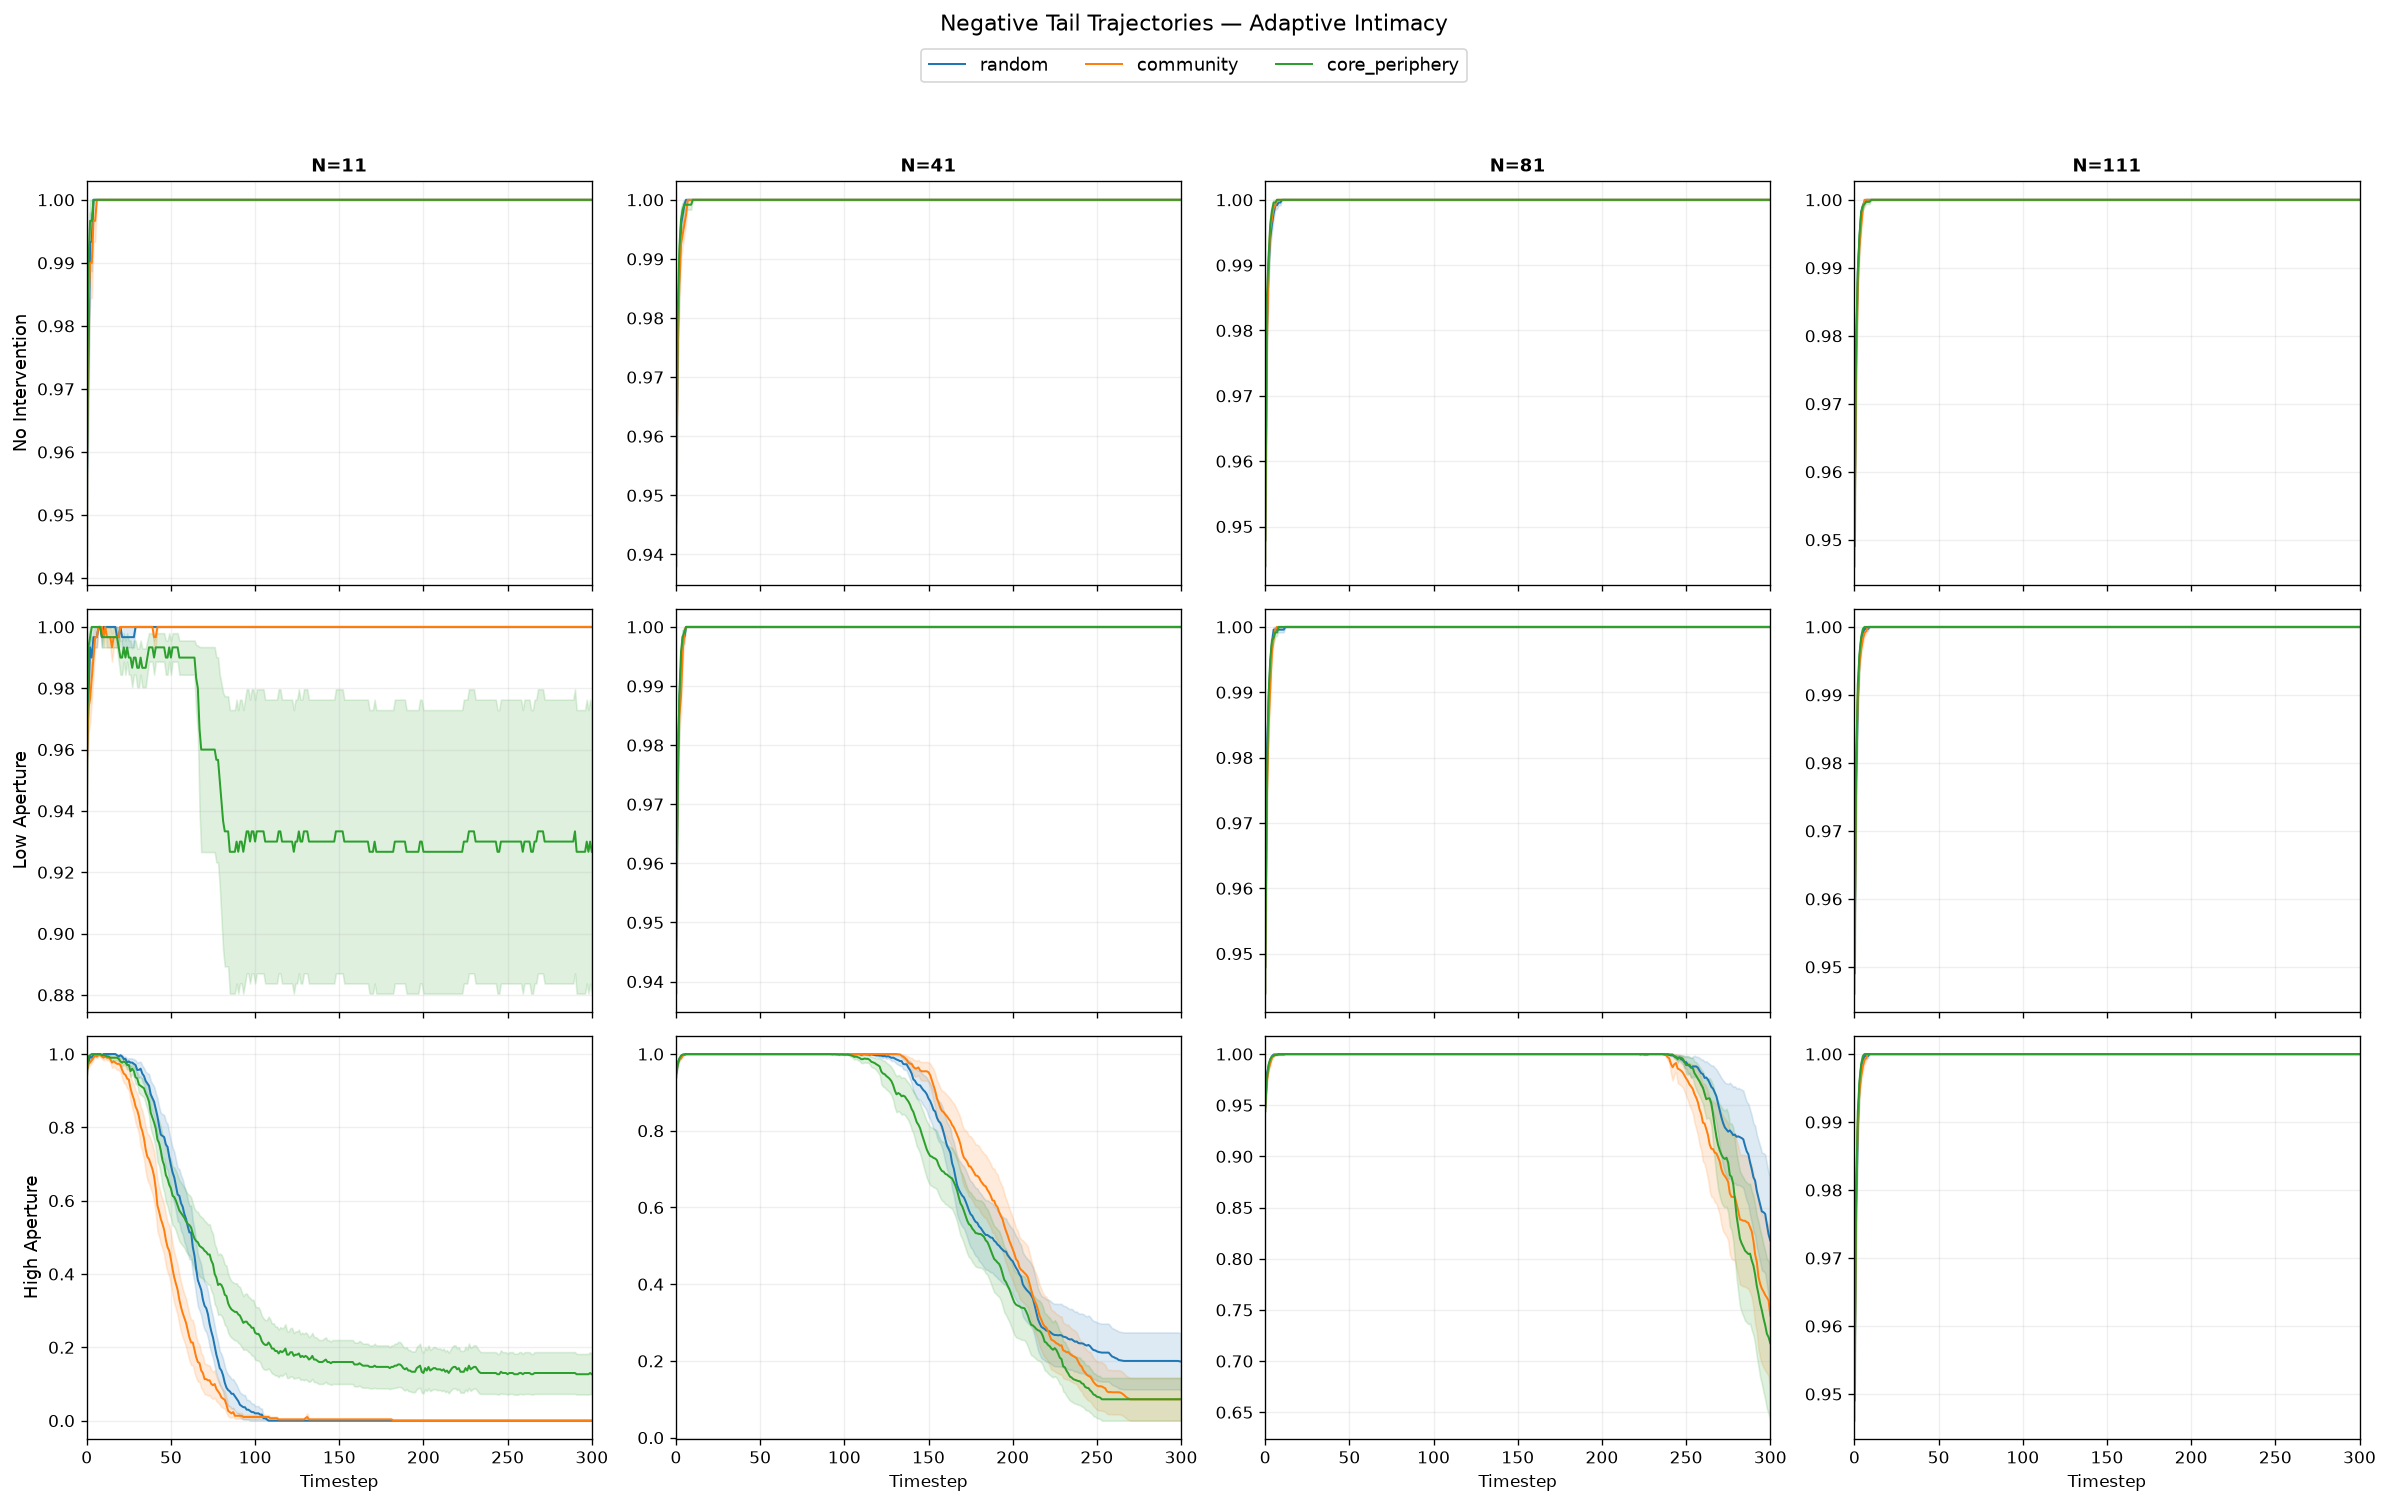

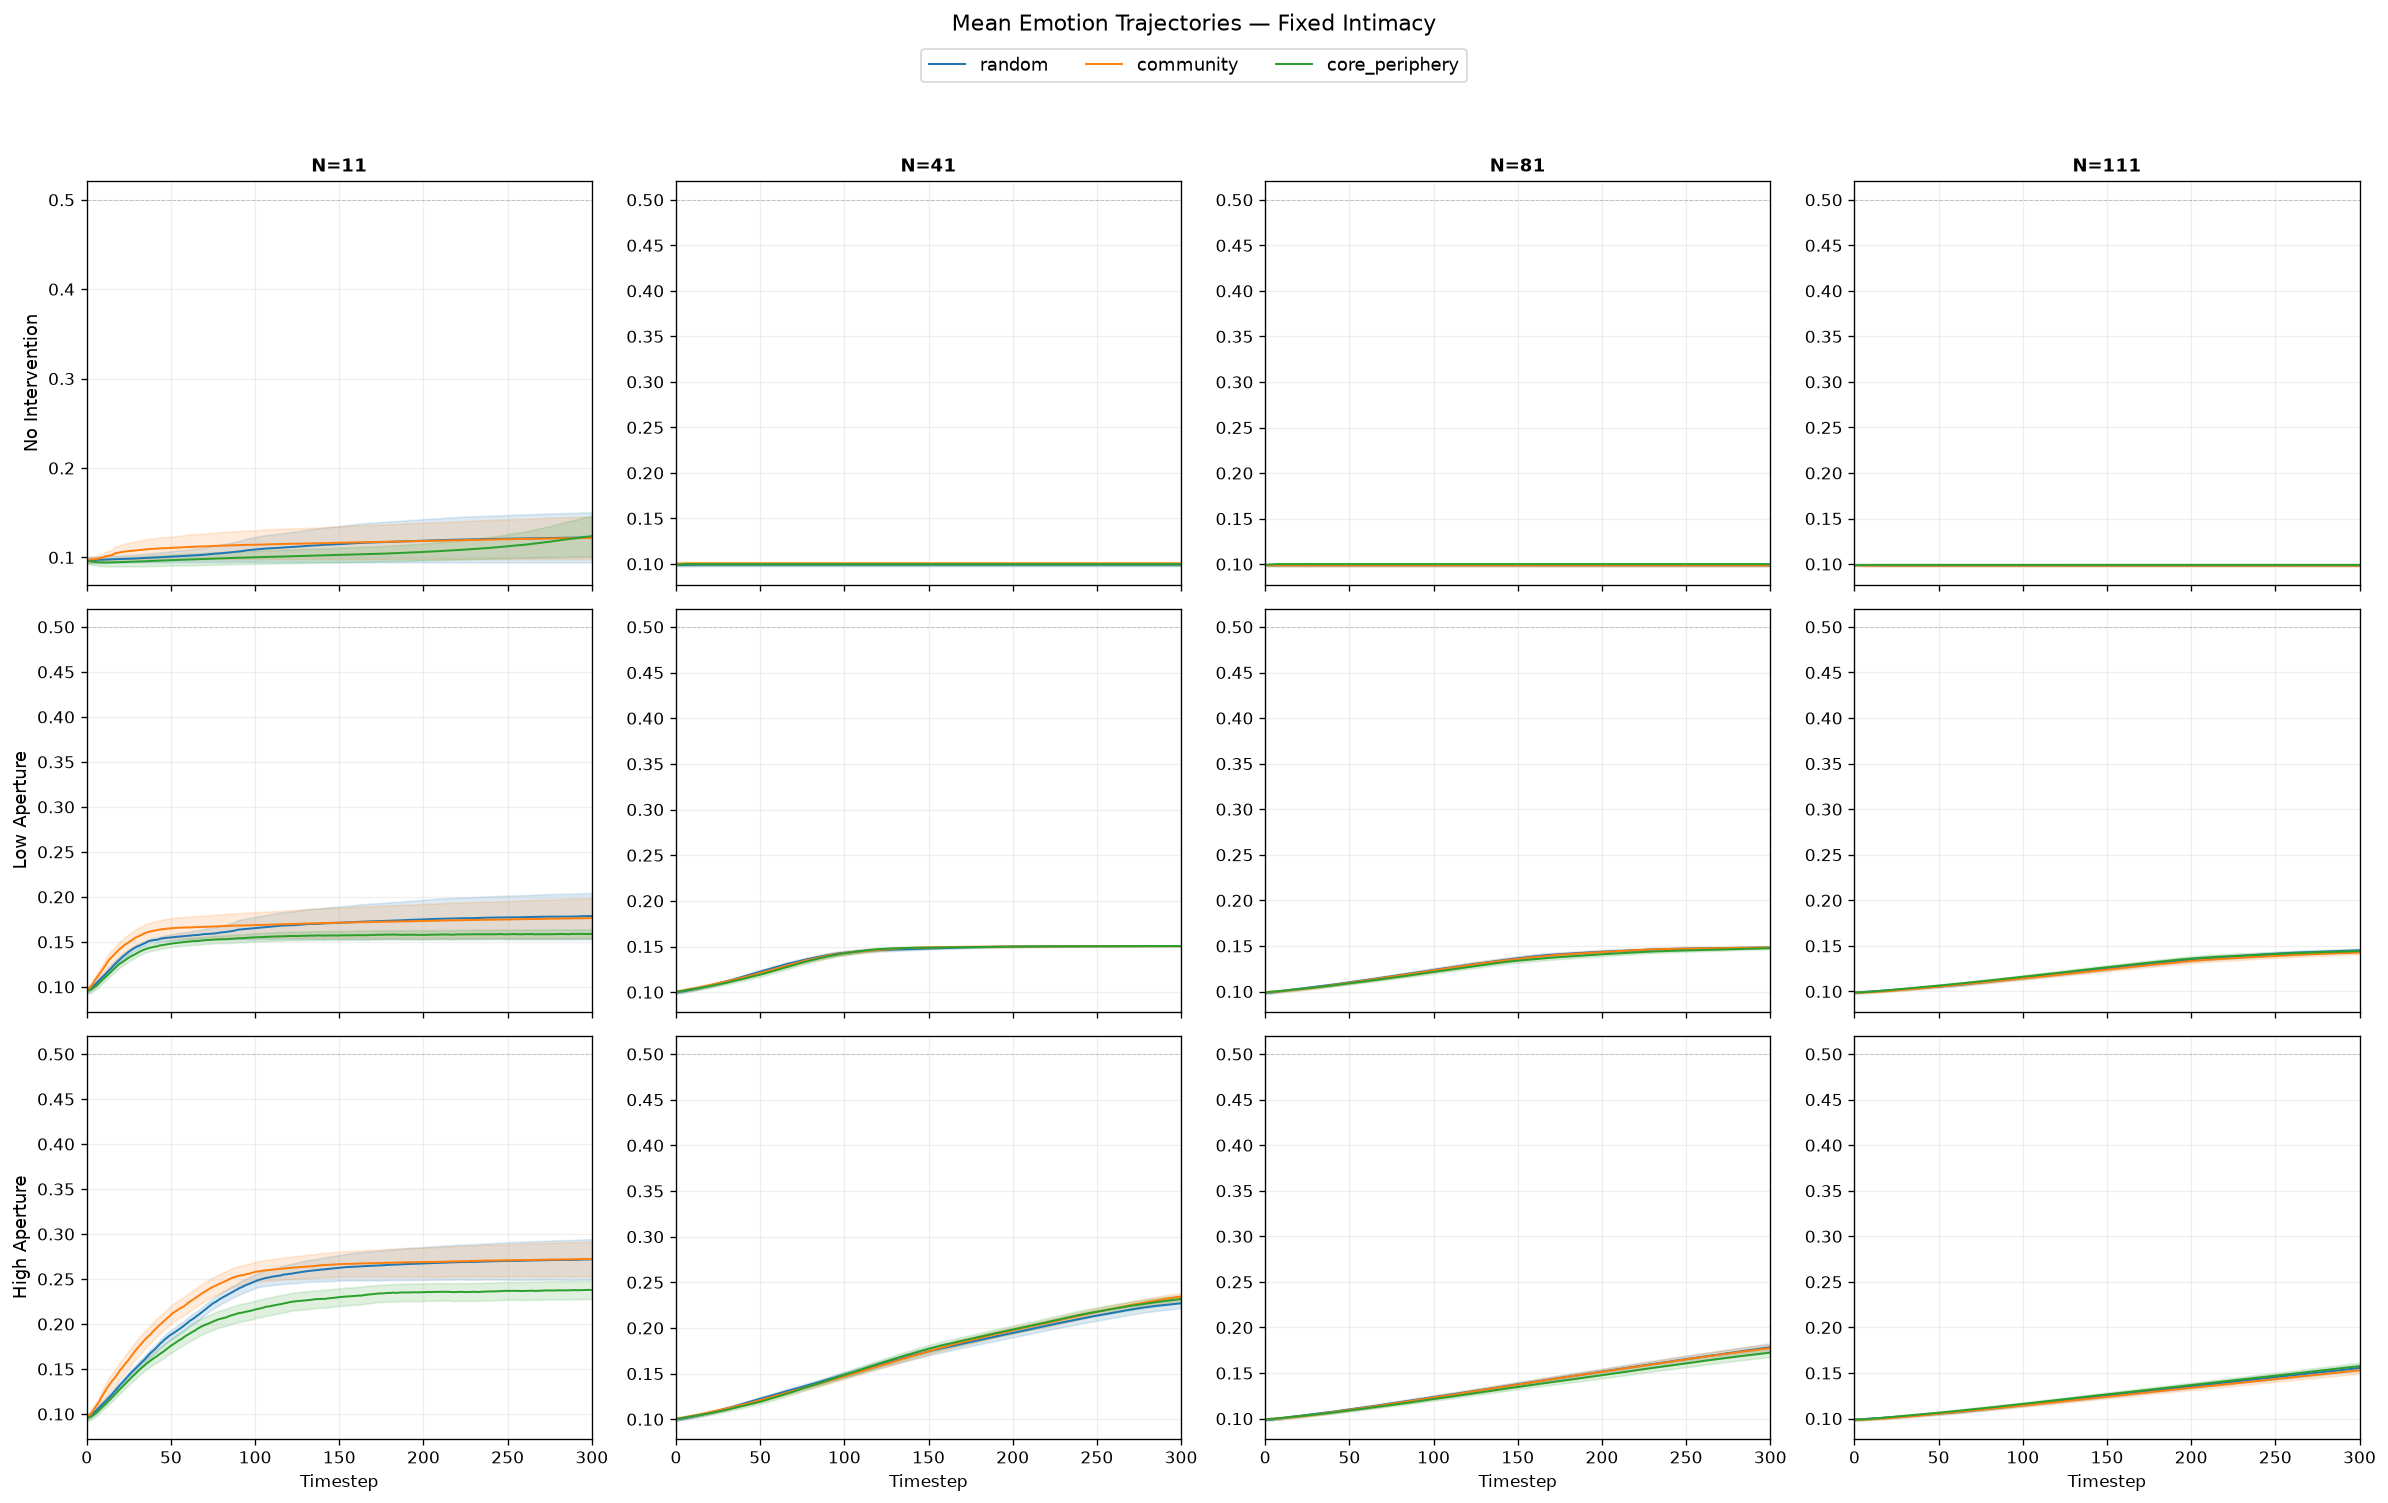

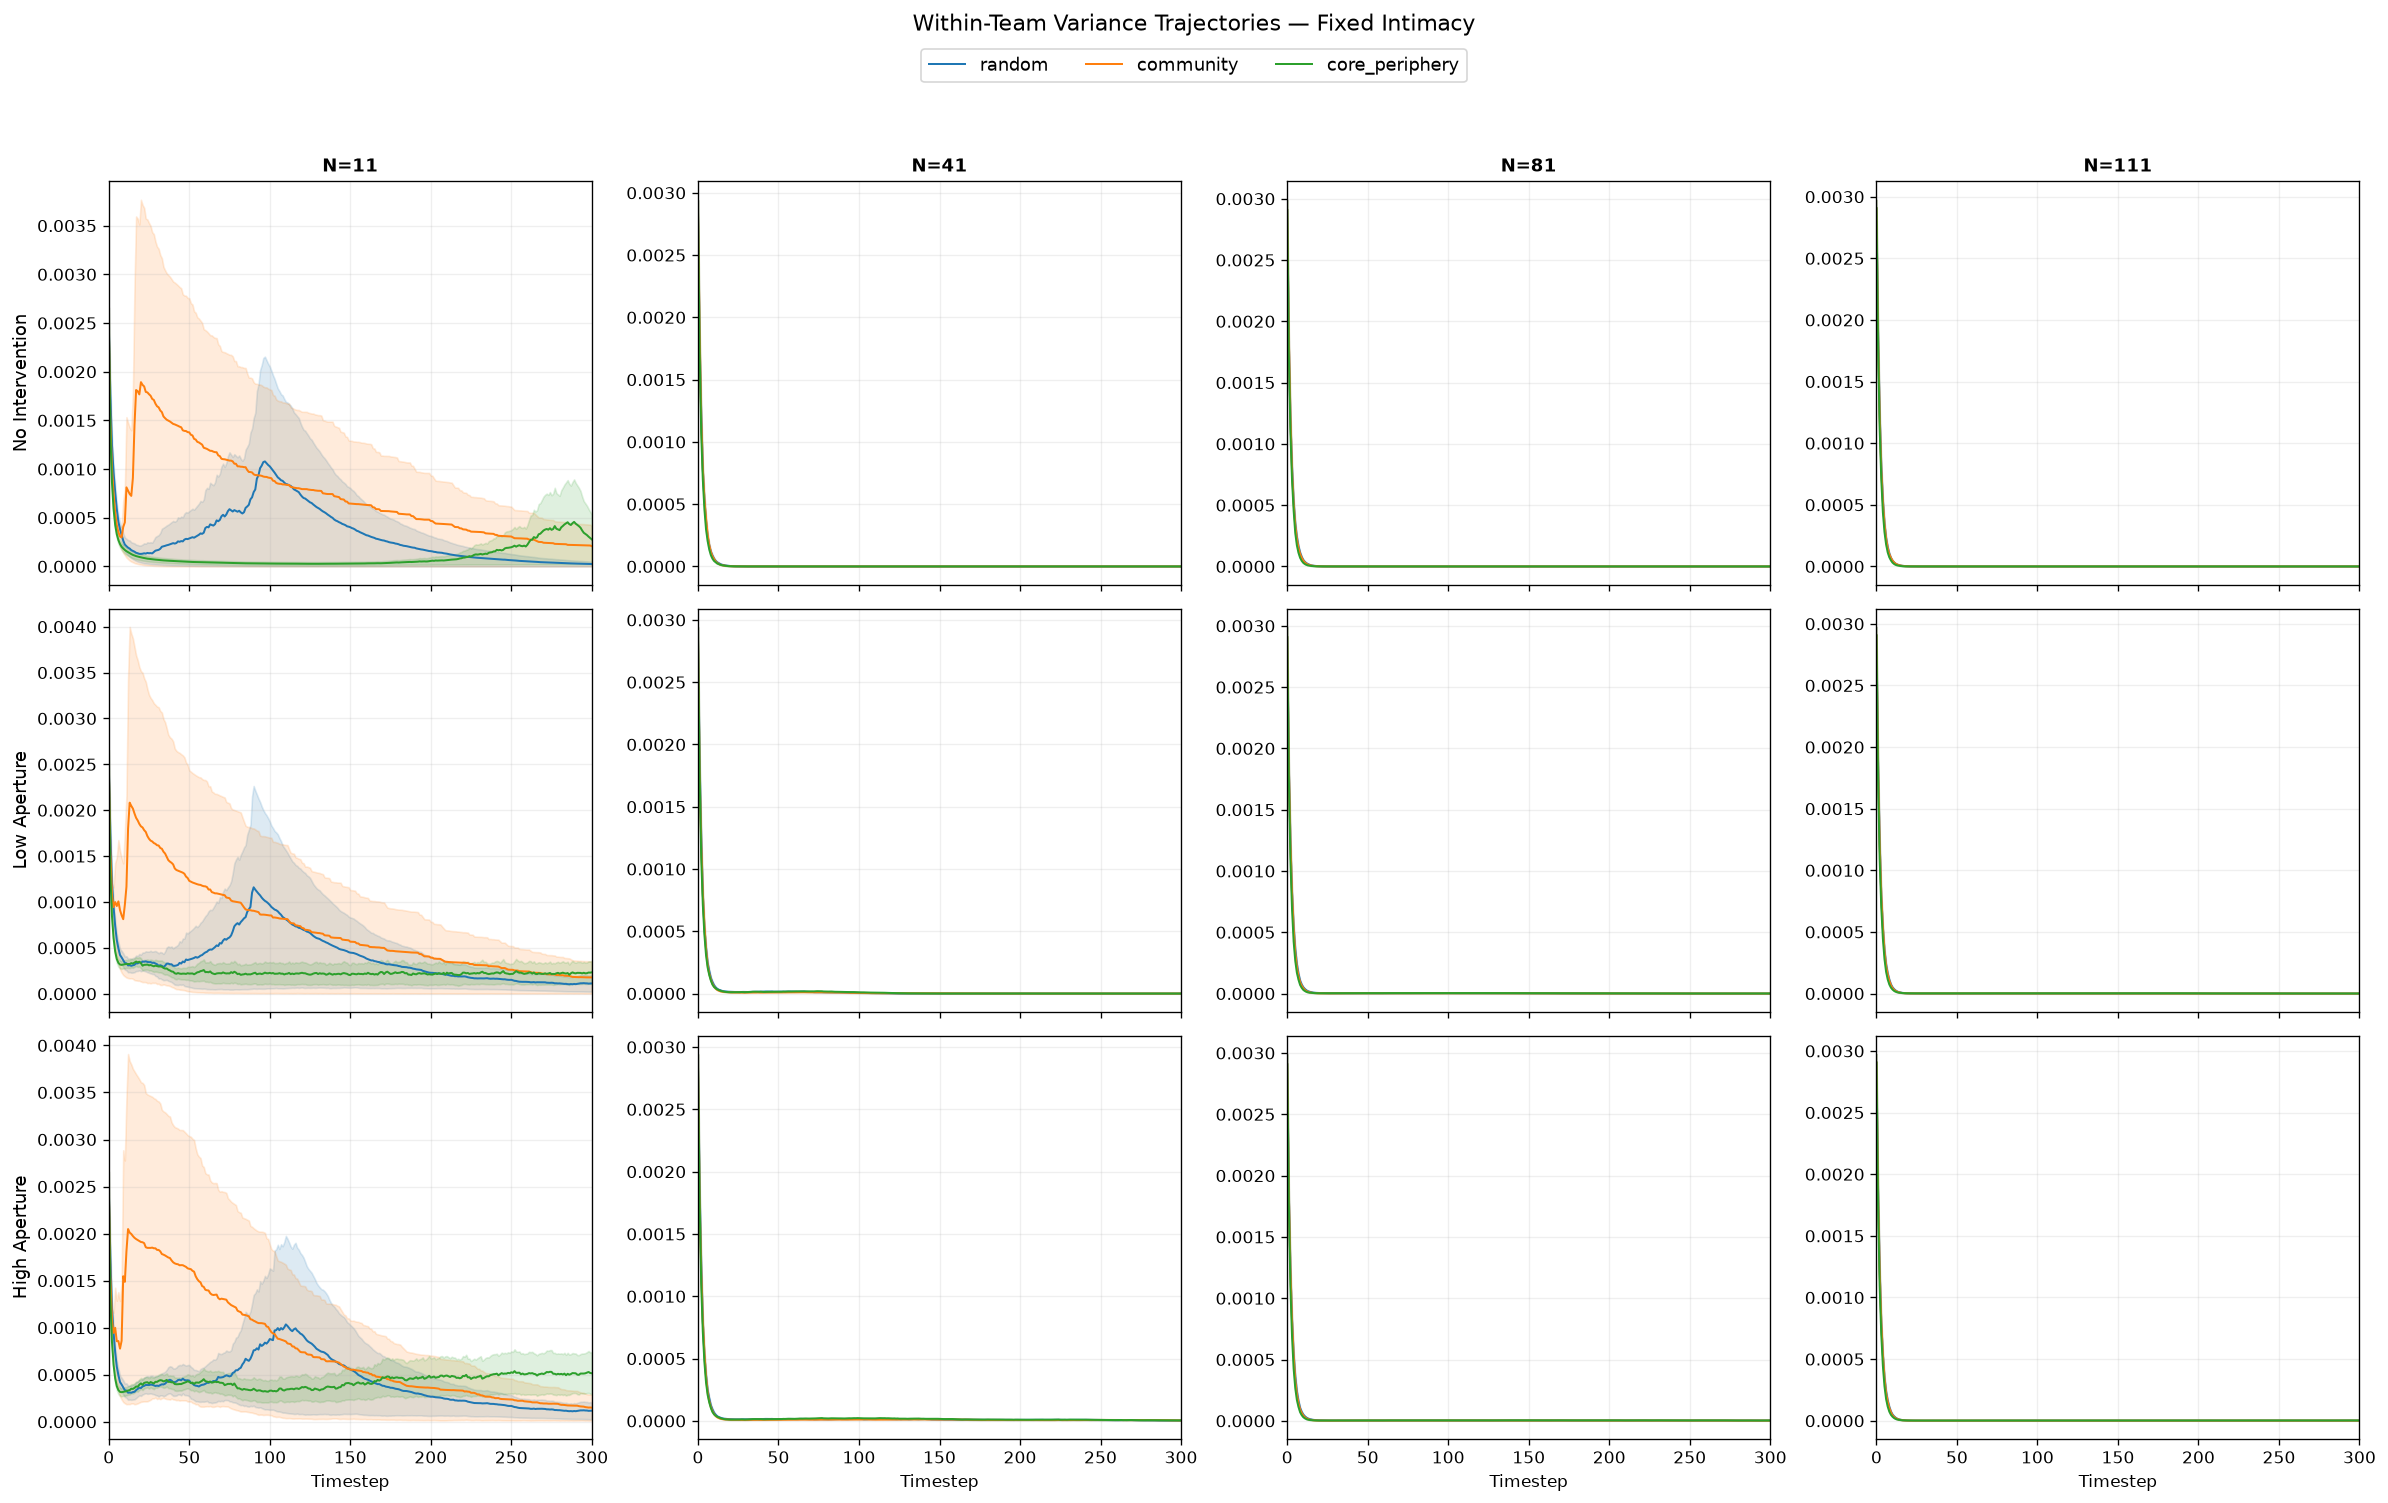

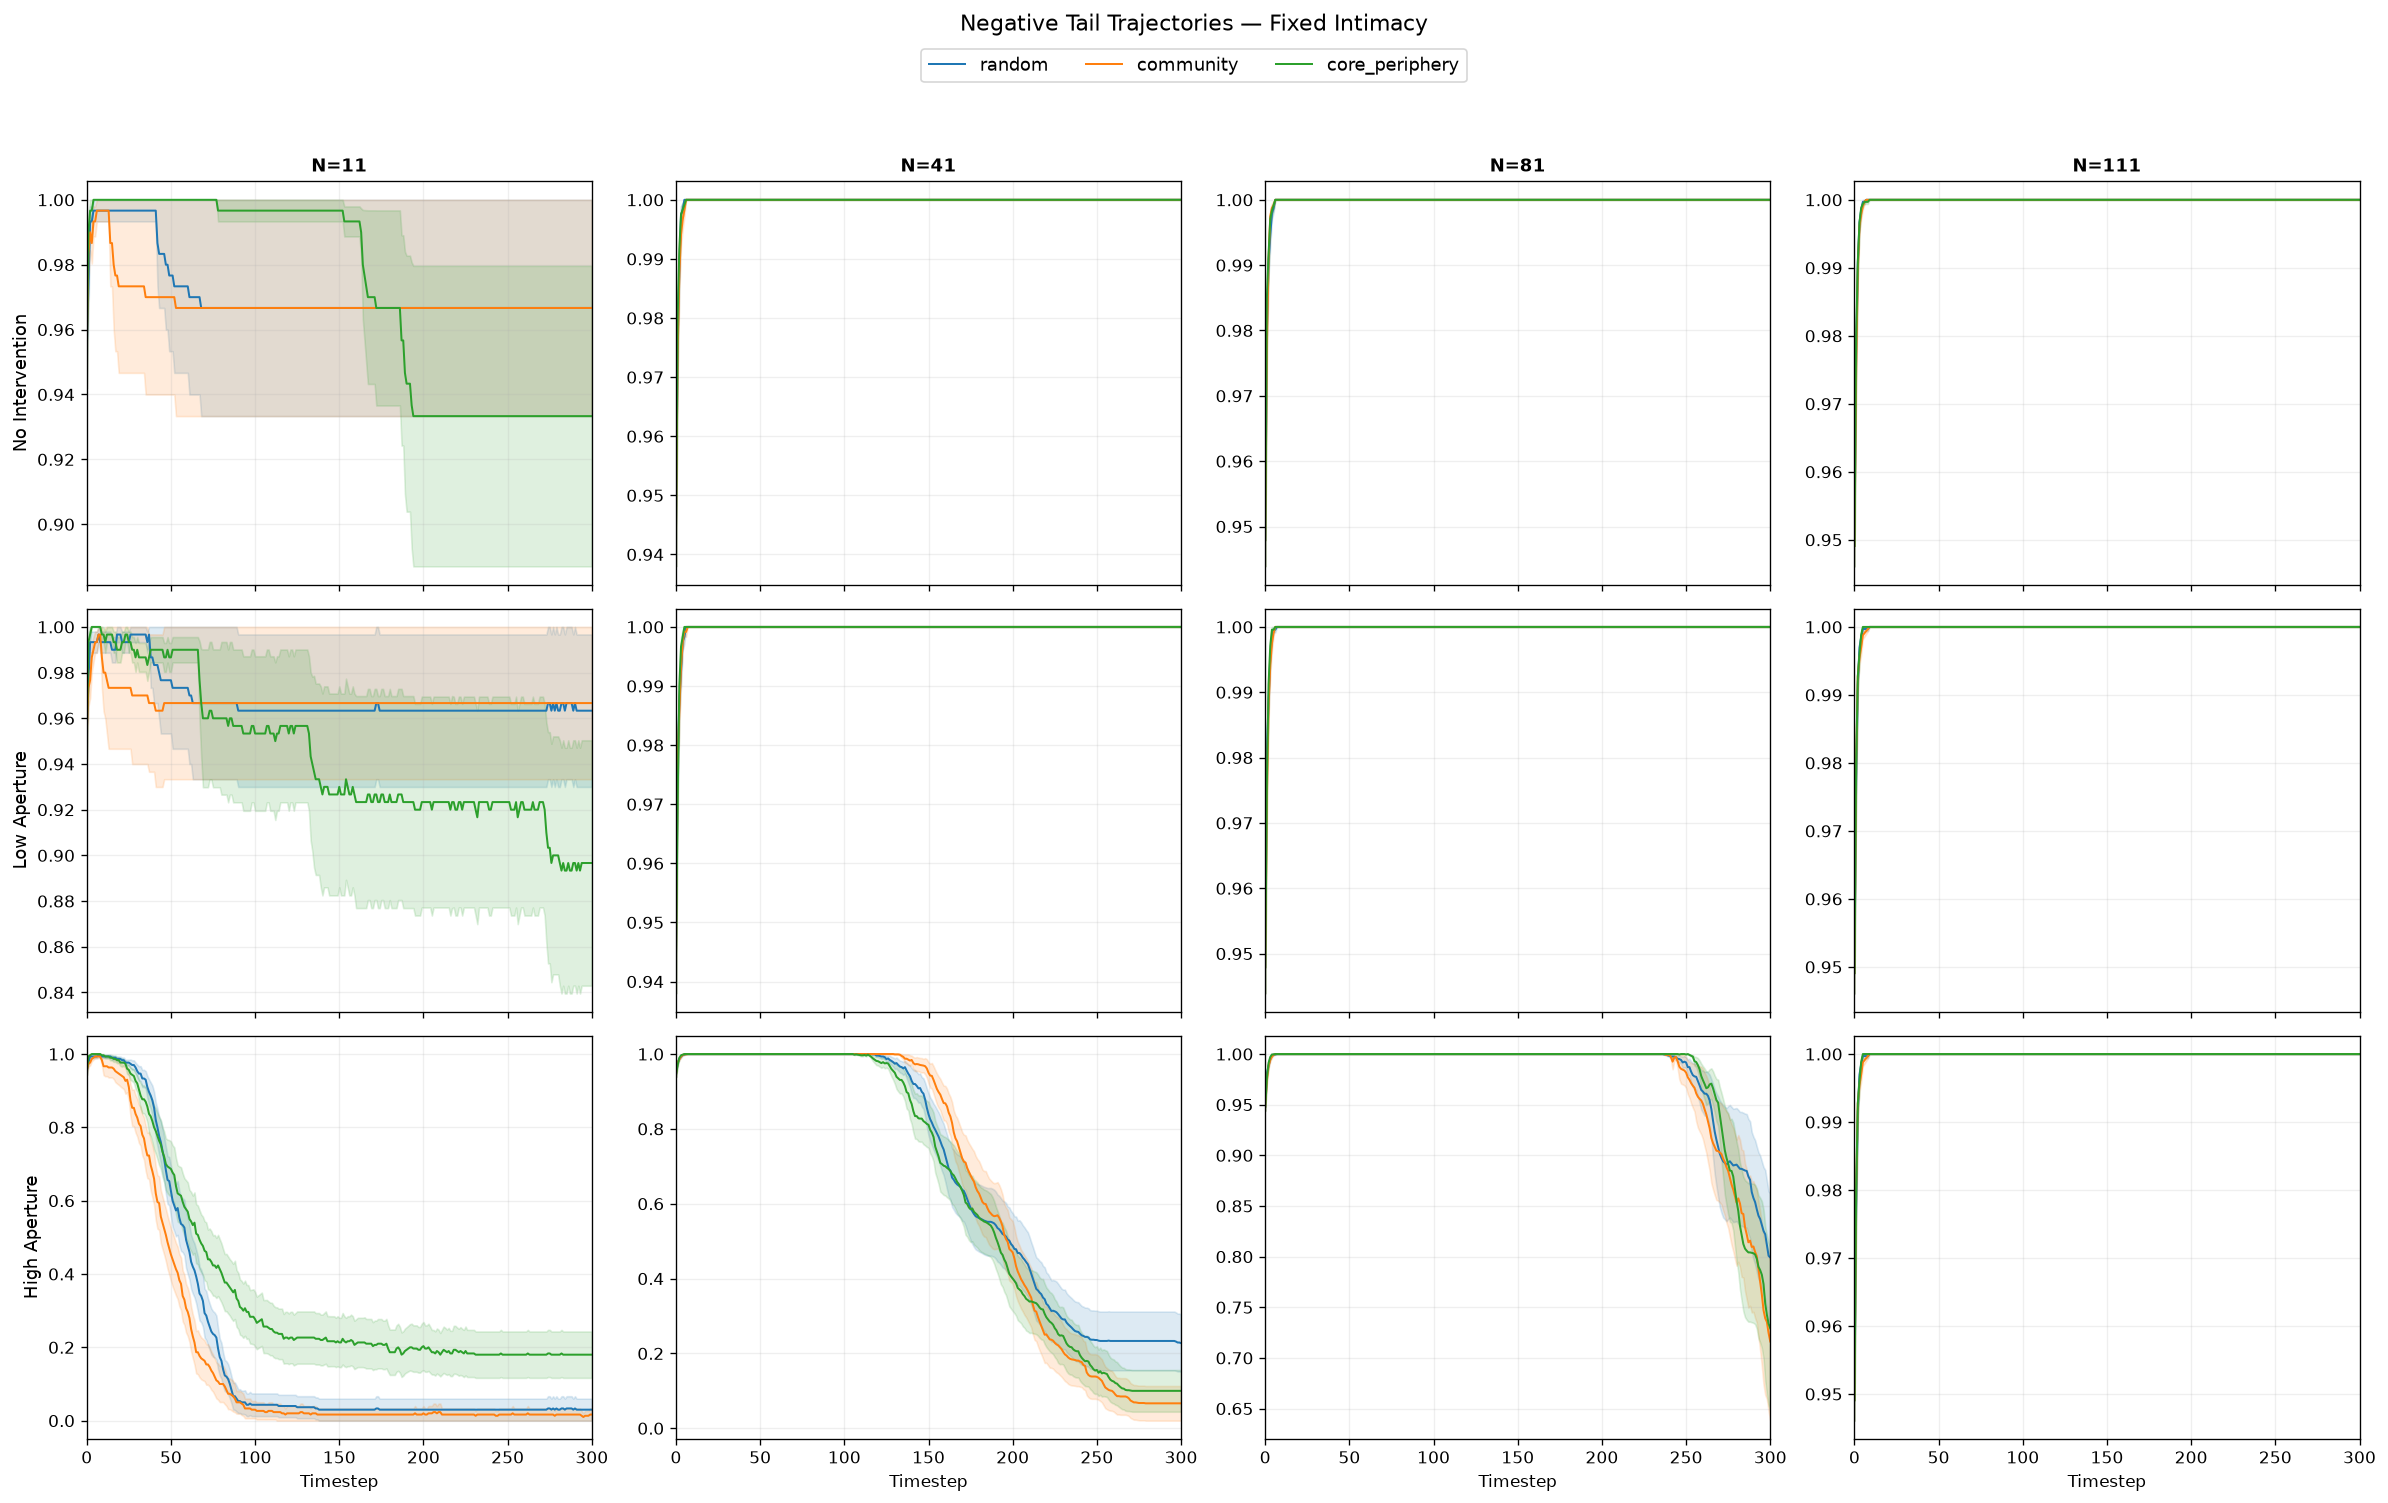

In [12]:
sizes = [11, 41, 81, 111]
Adaptivity = [True, False]
struct_colors = {
    'random': '#1f77b4',
    'community': '#ff7f0e',
    'core_periphery': '#2ca02c'
}

for adaptive in Adaptivity:
    traj_all = trajectory_df[trajectory_df['adaptive'] == adaptive].copy()

    # Aggregate across seeds
    agg_all = traj_all.groupby(['pop_size', 'structure', 'leader_style', 'timestep']).agg(
        mean_emotion=('avg_emotion', 'mean'), se_emotion=('avg_emotion', lambda x: x.std() / np.sqrt(x.count())),
        mean_var=('variance', 'mean'), se_var=('variance', lambda x: x.std() / np.sqrt(x.count())),
        mean_tail=('neg_tail', 'mean'), se_tail=('neg_tail', lambda x: x.std() / np.sqrt(x.count()))
    ).reset_index()

    cond_label = 'Adaptive' if adaptive else 'Fixed'
    metrics = [
        ('mean_emotion', 'se_emotion', 'Mean Emotion Trajectories', 'mean_emotion', True),
        ('mean_var', 'se_var', 'Within-Team Variance Trajectories', 'variance', False),
        ('mean_tail', 'se_tail', 'Negative Tail Trajectories', 'negative_tail', False)
    ]

    for mean_col, se_col, title, filename, reference_line in metrics:
        fig, axes = plt.subplots(3, len(sizes), figsize=(5 * len(sizes), 12), sharex=True)

        for col_idx, n in enumerate(sizes):
            for row_idx, (style, style_label) in enumerate(style_labels.items()):
                ax = axes[row_idx, col_idx]

                for struct in structure_order:
                    data = agg_all[(agg_all['pop_size'] == n) & (agg_all['leader_style'] == style) & (agg_all['structure'] == struct)]
                    if data.empty: continue

                    t = data['timestep'].values
                    mean = data[mean_col].values
                    se = data[se_col].values
                    color = struct_colors[struct]

                    ax.plot(t, mean, color=color, label=struct, linewidth=1.2)
                    ax.fill_between(t, mean - se, mean + se, color=color, alpha=0.15)

                if row_idx == 0: ax.set_title(f'N={n}', fontsize=11, fontweight='bold')
                if row_idx == 2: ax.set_xlabel('Timestep')
                if col_idx == 0: ax.set_ylabel(style_label, fontsize=11)
                if reference_line: ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=0.6, alpha=0.4)

                ax.set_xlim(0, max(agg_all['timestep']))
                ax.grid(True, alpha=0.2)

        handles, labels = axes[0, 0].get_legend_handles_labels()
        fig.legend(handles, labels, loc='upper center', ncol=3, fontsize=11, bbox_to_anchor=(0.5, 1.02))
        fig.suptitle(f'{title} — {cond_label} Intimacy\n', fontsize=13, y=1.04)
        plt.tight_layout()

        plt.savefig(f'../outputs/{filename}_{cond_label}.png', dpi=150, bbox_inches='tight')
        plt.show()

## 6. Manager intervention behavior table

Shows intervention count, first intervention timestep, and proportion of runs with any intervention.

In [11]:
POP_SIZE_T2 = 11
ADAPTIVE_T2 = True

subset_t2 = summary_df[(summary_df['pop_size'] == POP_SIZE_T2) & (summary_df['adaptive'] == ADAPTIVE_T2)].copy()

# Only show intervention styles (exclude No_Intervention)
intervention_styles = ['Low_Fully_Constrained', 'High_Fully_Constrained']

rows_t2 = []
for struct in structure_order:
    for style in intervention_styles:
        cell = subset_t2[(subset_t2['structure'] == struct) & (subset_t2['leader_style'] == style)]
        if len(cell) == 0:
            continue

        n_runs = len(cell)
        n_with_intervention = (cell['num_interventions'] > 0).sum()

        interventions_mean = cell['num_interventions'].mean()
        interventions_std = cell['num_interventions'].std()

        first_int = cell['first_intervention'].dropna()
        first_mean = first_int.mean() if len(first_int) > 0 else None

        any_prop = n_with_intervention / n_runs if n_runs > 0 else 0

        rows_t2.append({
            'Structure': struct,
            'Leader style': style,
            'Interventions': f'{interventions_mean:.1f} ({interventions_std:.1f})',
            'First intervention': f'{first_mean:.1f}' if first_mean else '—',
            'Any intervention': f'{any_prop:.2f}',
        })

table2 = pd.DataFrame(rows_t2)
cond_label = 'Adaptive' if ADAPTIVE_T2 else 'Fixed'
print(f'\nTable 2: Manager Intervention Behavior — N={POP_SIZE_T2}, {cond_label} intimacy')
print(f'(n={len(subset_t2)//9} runs per condition)')
print()
print(table2.to_string(index=False))


Table 2: Manager Intervention Behavior — N=11, Adaptive intimacy
(n=30 runs per condition)

     Structure           Leader style Interventions First intervention Any intervention
        random  Low_Fully_Constrained   27.1 (11.6)                1.9             1.00
        random High_Fully_Constrained   84.4 (15.0)                1.9             1.00
     community  Low_Fully_Constrained   22.5 (11.6)                1.8             1.00
     community High_Fully_Constrained   70.7 (19.6)                1.8             1.00
core_periphery  Low_Fully_Constrained   55.2 (80.2)                1.6             1.00
core_periphery High_Fully_Constrained  116.0 (78.4)                1.6             1.00
